In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [20]:
train_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\train'
valid_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\valid'
test_dir = r'C:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\project_4\cnn\classification_dataset\test'

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [22]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # 2 classes: Bird, Drone
])

model.summary()


c:\Users\Admin\Desktop\sb\ds_ml\internship\labmentix\venv_labmentix\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

""" checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True
) """


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [26]:
""" shift + alt + A to comment/uncomment """

""" history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)
 """

' history = model.fit(\n    train_data,\n    validation_data=valid_data,\n    epochs=20,\n    callbacks=[early_stop, checkpoint]\n)\n '

In [27]:
""" model.save("cnn_model_01.h5")
 """

' model.save("cnn_model_01.h5")\n '

In [28]:
'''
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.5682 - loss: 0.7099
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 813ms/step - accuracy: 0.6296 - loss: 0.6366 - val_accuracy: 0.7014 - val_loss: 0.5511
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.6945 - loss: 0.5846
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.7126 - loss: 0.5627 - val_accuracy: 0.7217 - val_loss: 0.5176
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.7525 - loss: 0.4951
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 514ms/step - accuracy: 0.7663 - loss: 0.4798 - val_accuracy: 0.7805 - val_loss: 0.4509
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 528ms/step - accuracy: 0.7656 - loss: 0.4768 - val_accuracy: 0.7511 - val_loss: 0.4930
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 521ms/step - accuracy: 0.7866 - loss: 0.4539 - val_accuracy: 0.7421 - val_loss: 0.5027
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.8073 - loss: 0.4151 - val_accuracy: 0.7647 - val_loss: 0.4583
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8026 - loss: 0.4167
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 526ms/step - accuracy: 0.8171 - loss: 0.3897 - val_accuracy: 0.8032 - val_loss: 0.4747
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.8200 - loss: 0.4050
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 536ms/step - accuracy: 0.8276 - loss: 0.3810 - val_accuracy: 0.8281 - val_loss: 0.4076
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 536ms/step - accuracy: 0.8317 - loss: 0.3784 - val_accuracy: 0.7986 - val_loss: 0.4533
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 523ms/step - accuracy: 0.8509 - loss: 0.3382 - val_accuracy: 0.7873 - val_loss: 0.5354
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8409 - loss: 0.3493
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 631ms/step - accuracy: 0.8486 - loss: 0.3442 - val_accuracy: 0.8484 - val_loss: 0.4270
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.8474 - loss: 0.3181
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 759ms/step - accuracy: 0.8580 - loss: 0.3190 - val_accuracy: 0.8756 - val_loss: 0.3443
Epoch 13/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 535ms/step - accuracy: 0.8708 - loss: 0.3025 - val_accuracy: 0.8348 - val_loss: 0.4067
Epoch 14/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 543ms/step - accuracy: 0.8633 - loss: 0.3165 - val_accuracy: 0.8394 - val_loss: 0.3737
Epoch 15/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 519ms/step - accuracy: 0.8775 - loss: 0.2908 - val_accuracy: 0.8281 - val_loss: 0.4210
Epoch 16/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - accuracy: 0.8869 - loss: 0.2653 - val_accuracy: 0.8371 - val_loss: 0.4646
Epoch 17/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 527ms/step - accuracy: 0.8835 - loss: 0.2784 - val_accuracy: 0.8529 - val_loss: 0.4034
'''

"\nEpoch 1/20\n84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.5682 - loss: 0.7099\nWARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. \n84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 813ms/step - accuracy: 0.6296 - loss: 0.6366 - val_accuracy: 0.7014 - val_loss: 0.5511\nEpoch 2/20\n84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.6945 - loss: 0.5846\nWARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. \n84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.7126 - loss: 0.5627 - val_accuracy: 0.7217 - val_loss: 0

In [29]:
from tensorflow.keras.models import load_model
model = load_model("cnn_model_01.h5")


In [30]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8837 - loss: 0.3295
Test Accuracy: 0.8837209343910217
Test Loss: 0.32947832345962524


In [34]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype("int").reshape(-1)
y_true = test_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


In [35]:
from sklearn.metrics import classification_report

target_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=target_names))


              precision    recall  f1-score   support

        bird       0.91      0.88      0.89       121
       drone       0.85      0.89      0.87        94

    accuracy                           0.88       215
   macro avg       0.88      0.88      0.88       215
weighted avg       0.89      0.88      0.88       215



Text(0.5, 1.0, 'Confusion Matrix')

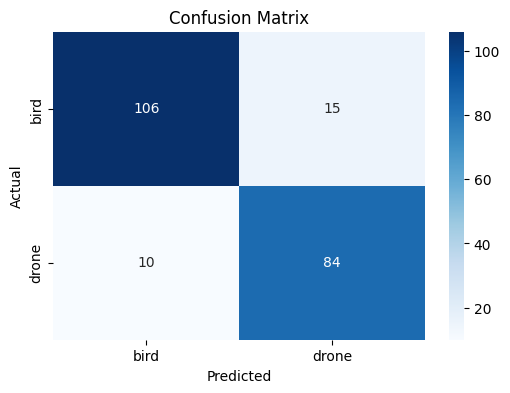

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")